In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


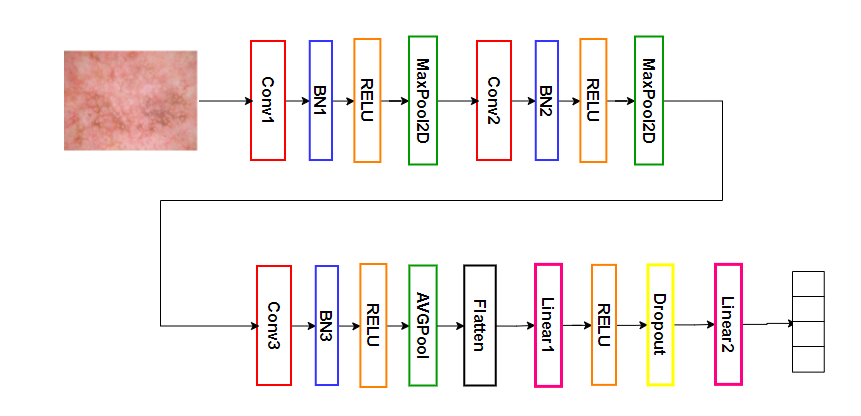

In [14]:
# ── Model v2 – no nn.Sequential, 3 conv layers ────────────────────────────────
class SkinConvNetV1(nn.Module):
    """3-layer ConvNet written with explicit layer attributes (no nn.Sequential)."""

    def __init__(self, num_classes: int = 5):
        super().__init__()

        # ── Conv blocks ──────────────────────────────────────────────────────
        # Block 1 – 3 → 32
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm2d(32)

        # Block 2 – 32 → 64
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm2d(64)

        # Block 3 – 64 → 128
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3   = nn.BatchNorm2d(128)

        self.pool    = nn.MaxPool2d(2)
        self.avgpool = nn.AdaptiveAvgPool2d(4)
        self.relu    = nn.ReLU(inplace=True)

        # ── Classifier ───────────────────────────────────────────────────────
        self.flatten = nn.Flatten()
        self.fc1     = nn.Linear(128 * 4 * 4, 256)
        self.dropout = nn.Dropout(0.5)
        self.fc2     = nn.Linear(256, num_classes)

    def forward(self, x):
        # Block 1
        x = self.relu(self.bn1(self.conv1(x)))   # 3×128×128  → 32×128×128
        x = self.pool(x)                          # → 32×64×64

        # Block 2
        x = self.relu(self.bn2(self.conv2(x)))   # → 64×64×64
        x = self.pool(x)                          # → 64×32×32

        # Block 3
        x = self.relu(self.bn3(self.conv3(x)))   # → 128×32×32
        x = self.avgpool(x)                       # → 128×4×4

        # Classifier
        x = self.flatten(x)                       # → 2048
        x = self.relu(self.fc1(x))               # → 256
        x = self.dropout(x)
        x = self.fc2(x)                           # → num_classes
        return x

In [15]:
model1 = SkinConvNetV1(num_classes=5)

rand_img = torch.randn(1, 3, 128, 128)
print(rand_img.shape)  # Simulate a random image (batch_size=1, channels=3, height=128, width=128)
output = model1(rand_img)

print(output)
print(output.shape)  # should be torch.Size([1, 5])

torch.Size([1, 3, 128, 128])
tensor([[ 0.0818, -0.0349, -0.0026,  0.1206,  0.2595]],
       grad_fn=<AddmmBackward0>)
torch.Size([1, 5])


In [16]:
# ── Model ─────────────────────────────────────────────────────────────────────
class SkinConvNetV2(nn.Module):
    """Simple 4-layer ConvNet for skin-lesion classification."""

    def __init__(self, num_classes: int = 5):
        super().__init__()

        self.features = nn.Sequential(
            # Block 1 – 3 → 32
            nn.Conv2d(3, 32, kernel_size=3, padding=1),   # 128×128
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                               # 64×64

            # Block 2 – 32 → 64
            nn.Conv2d(32, 64, kernel_size=3, padding=1),  # 64×64
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                               # 32×32

            # Block 3 – 64 → 128
            nn.Conv2d(64, 128, kernel_size=3, padding=1), # 32×32
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                               # 16×16

            # Block 4 – 128 → 256
            nn.Conv2d(128, 256, kernel_size=3, padding=1),# 16×16
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d(4),                       # 4×4 (fixed output size)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [17]:
from torchvision import models

# ── ResNet-based model ─────────────────────────────────────────────────────────
class SkinLesionResNet(nn.Module):
    """Fine-tuned ResNet-18 for skin-lesion classification."""

    def __init__(self, num_classes: int = 5):
        super().__init__()
        weights = models.ResNet18_Weights.DEFAULT 
        backbone = models.resnet18(weights=weights)

        # Replace the final FC layer to match num_classes
        in_features = backbone.fc.in_features          # 512 for ResNet-18
        backbone.fc = nn.Linear(in_features, num_classes)

        self.model = backbone

    def forward(self, x):
        return self.model(x)

In [18]:
import os
import random
from glob import glob
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# ── Custom Dataset with built-in split ────────────────────────────────────────
class SkinLesionDataset(Dataset):
    """
    Loads all images from a folder tree, performs a random
    train / val / test split inside the constructor.

    folder structure:
        root/
          class_A/img1.jpg ...
          class_B/img2.jpg ...

    Usage:
        train_ds = SkinLesionDataset(root, split="train")
        val_ds   = SkinLesionDataset(root, split="val")
        test_ds  = SkinLesionDataset(root, split="test")
    """

    def __init__(
        self,
        root: str,
        split: str = "train",       # "train" | "val" | "test"
        train_ratio: float = 0.70,
        val_ratio:   float = 0.15,  # test_ratio = 1 - train_ratio - val_ratio
        transform=None,
        seed: int = 42,
    ):
        assert split in ("train", "val", "test"), "split must be 'train', 'val', or 'test'"
        self.transform = transform

        # ── 1. Collect all paths and build class→index mapping ────────────
        paths = glob(os.path.join(root, "*", "*"))
        label_names = [os.path.basename(os.path.dirname(p)) for p in paths]

        self.classes      = sorted(set(label_names))
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.classes)}

        # per-image integer labels
        int_labels = [self.class_to_idx[lbl] for lbl in label_names]

        # ── 2. Shuffle with fixed seed ────────────────────────────────────
        data = list(zip(paths, int_labels))
        random.seed(seed)
        random.shuffle(data)
        all_paths, all_labels = zip(*data)

        # ── 3. Slice into splits ──────────────────────────────────────────
        num_total = len(all_paths)
        num_train = int(train_ratio * num_total)
        num_val   = int(val_ratio   * num_total)

        if split == "train":
            self.file_paths = list(all_paths[:num_train])
            self.labels     = list(all_labels[:num_train])
        elif split == "val":
            self.file_paths = list(all_paths[num_train : num_train + num_val])
            self.labels     = list(all_labels[num_train : num_train + num_val])
        else:  # test
            self.file_paths = list(all_paths[num_train + num_val :])
            self.labels     = list(all_labels[num_train + num_val :])

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        img   = Image.open(self.file_paths[idx]).convert("RGB")
        label = self.labels[idx]
        if self.transform:
            img = self.transform(img)
        return img, label


In [19]:
IMG_SIZE   = 128


_mean = [0.485, 0.456, 0.406]
_std  = [0.229, 0.224, 0.225]

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(_mean, _std),
])

In [20]:
# train, val, test datasets
train_ds = SkinLesionDataset(root="/blue/bme6938/share/Datasets/SkinLesions", split="train", transform = transform, seed=42)
val_ds   = SkinLesionDataset(root="/blue/bme6938/share/Datasets/SkinLesions", split="val",     transform = transform, seed=42)
test_ds  = SkinLesionDataset(root="/blue/bme6938/share/Datasets/SkinLesions", split="test",    transform = transform, seed=42)

num_classes = len(train_ds.classes)

In [21]:
# ── DataLoaders ───────────────────────────────────────────────────────────────
BATCH_SIZE = 10
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

In [22]:
model = SkinConvNetV2(num_classes=num_classes)
model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

for epoch in range(50):
    # ── Training ──────────────────────────────────────────────────────────
    model.train()
    train_loss, train_correct = 0.0, 0

    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, lbls)
        loss.backward()
        optimizer.step()

        train_loss    += loss.item() * imgs.size(0)
        train_correct += (outputs.argmax(1) == lbls).sum().item()

    train_loss /= len(train_loader.dataset)
    train_acc   = train_correct / len(train_loader.dataset)

    # ── Validation ────────────────────────────────────────────────────────
    model.eval()
    val_loss, val_correct = 0.0, 0

    with torch.no_grad():
        for imgs, lbls in val_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            outputs = model(imgs)
            loss    = criterion(outputs, lbls)

            val_loss    += loss.item() * imgs.size(0)
            val_correct += (outputs.argmax(1) == lbls).sum().item()

    val_loss /= len(val_loader.dataset)
    val_acc   = val_correct / len(val_loader.dataset)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch:02d} | "
          f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.3f} | "
          f"Val   Loss: {val_loss:.4f}  Acc: {val_acc:.3f}")


Epoch 00 | Train Loss: 1.6470  Acc: 0.344 | Val   Loss: 1.3035  Acc: 0.397
Epoch 01 | Train Loss: 1.3039  Acc: 0.442 | Val   Loss: 1.2639  Acc: 0.482
Epoch 02 | Train Loss: 1.2410  Acc: 0.498 | Val   Loss: 1.1414  Acc: 0.513
Epoch 03 | Train Loss: 1.1798  Acc: 0.516 | Val   Loss: 1.0855  Acc: 0.513
Epoch 04 | Train Loss: 1.1240  Acc: 0.544 | Val   Loss: 1.1038  Acc: 0.527
Epoch 05 | Train Loss: 1.1162  Acc: 0.547 | Val   Loss: 1.0343  Acc: 0.607
Epoch 06 | Train Loss: 1.0454  Acc: 0.560 | Val   Loss: 1.0936  Acc: 0.531
Epoch 07 | Train Loss: 0.9850  Acc: 0.608 | Val   Loss: 1.0265  Acc: 0.545
Epoch 08 | Train Loss: 0.9940  Acc: 0.595 | Val   Loss: 1.1991  Acc: 0.500
Epoch 09 | Train Loss: 0.9594  Acc: 0.612 | Val   Loss: 1.0248  Acc: 0.585
Epoch 10 | Train Loss: 0.9352  Acc: 0.623 | Val   Loss: 1.0473  Acc: 0.594
Epoch 11 | Train Loss: 0.8748  Acc: 0.662 | Val   Loss: 0.9562  Acc: 0.589
Epoch 12 | Train Loss: 0.7905  Acc: 0.688 | Val   Loss: 1.0141  Acc: 0.540
Epoch 13 | Train Loss: 0.

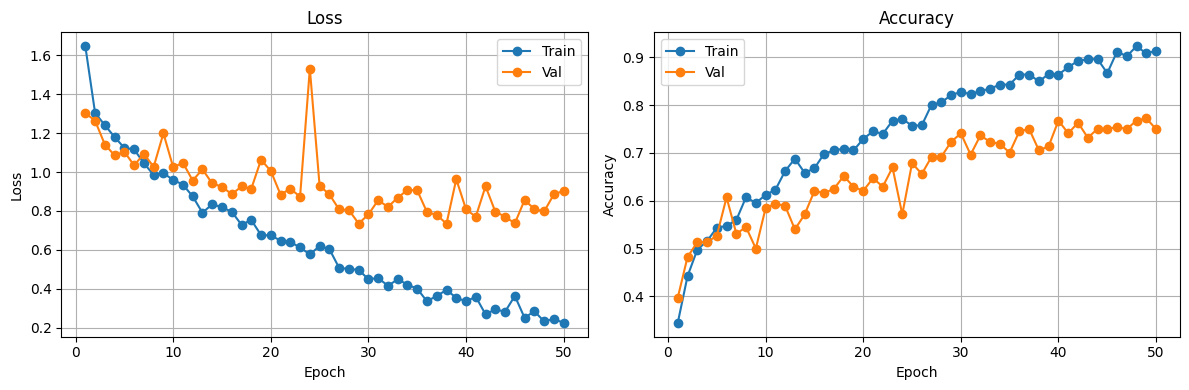

In [23]:
import matplotlib.pyplot as plt

epochs = range(1, len(history["train_loss"]) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# ── Loss ──────────────────────────────────────────────────────────────────────
ax1.plot(epochs, history["train_loss"], label="Train", marker="o")
ax1.plot(epochs, history["val_loss"],   label="Val",   marker="o")
ax1.set_title("Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.grid(True)

# ── Accuracy ──────────────────────────────────────────────────────────────────
ax2.plot(epochs, history["train_acc"], label="Train", marker="o")
ax2.plot(epochs, history["val_acc"],   label="Val",   marker="o")
ax2.set_title("Accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()
